## Anamoly Detection :----

(i)   Anamoly Detection is a process of identifying the unusual data points that is different from rest of the data points.

(ii)  It is also different from the normal behaviour of the data points.


## Applications of Anamoly Detection :-------------

(i)  Credit Card Fraud Detection

(ii) Medical diagnosis

## Problem Statement :----------

(i) The main aim of the problem statement is to build an Autoencoder neural network based model on the creditcard dataset so as to identify all the anamolies from the dataset.

## Project Workflow:--------

1. Import Libraries

2. Load Dataset

3. Data Exploration

4. Data Preprocessing

4. Exploratory Data Analysis

5. Train-Test Split

6. Build AutoEncoder Model

7. Train Model

8. Reconstruction Error Calculation

9. Threshold Selection

10. Detect Anomalies

11. Model Evaluation

12. Visualization

## **Step 1: Import all the necessary Libraries**

In [309]:
import  numpy               as  np
import  pandas              as  pd
import  matplotlib.pyplot   as  plt
import  seaborn             as  sns

from    sklearn.model_selection     import  train_test_split
from    sklearn.preprocessing       import  StandardScaler
from    sklearn.metrics             import  accuracy_score, confusion_matrix, classification_report

from    tensorflow.keras.models     import  Model
from    tensorflow.keras.layers     import  Input,Dense
from    tensorflow.keras.callbacks  import  EarlyStopping

## **Step 2: Load the dataset**

In [310]:
#### Load the dataset

df = pd.read_csv("/content/creditcard.csv")

In [311]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## **Step 3: Perform the Data Exploration**

In [312]:
#### display the first five rows of the dataset

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [313]:
#### display the last five rows of the dataset

df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [314]:
#### get the length of the dataset

print('Length of the dataset is:', len(df))

Length of the dataset is: 284807


In [315]:
#### get the shape of the dataset

print('Shape of the dataset is:', df.shape)

Shape of the dataset is: (284807, 31)


In [316]:
#### get the columns used in the dataset

df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [317]:
#### get the information about the columns used in the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

## OBSERVATIONS:

1.  All the independent features are floating in nature.

2.  The target variable 'Class' which is the output is integer in nature.

In [318]:
#### get the descriptive information for each numerical column in the dataset

df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## OBSERVATIONS:

1.  The above table depicts about the information of the statistical summary for each numerical column used in the dataset.

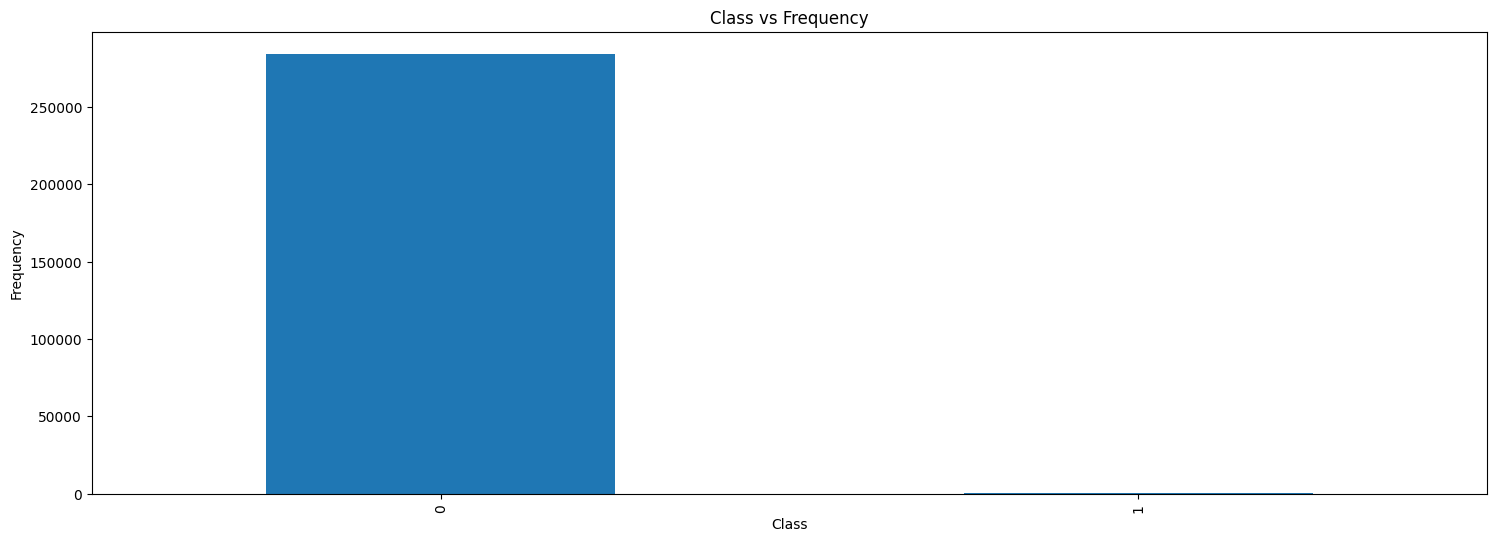

In [319]:
#### perform the graphical representation for the categorical count in the 'Class' column

plt.figure(figsize=(18,6))
df['Class'].value_counts().plot(kind='bar')
plt.title('Class vs Frequency')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.show()

## OBSERVATIONS:

1.  From the above graph, it is seen that the frequency count of the class 0 (normal transactions) is much higher than the fraud transactions.

2.  So, it is a highly imbalanced dataset.

## **Step 4: Perform the Data Cleaning and Feature Engineering**

In [320]:
#### Perform the downsampling on the majority class to make it a balanced dataset


from  sklearn.utils  import  resample

df_majority = df[df.Class==0]
df_minority = df[df.Class==1]

#### perform downsampling on the majority class

df_majority_downsampled = resample(
    df_majority                   ,
    replace=True                  ,
    n_samples=len(df_minority)    ,
    random_state=123
)

In [321]:
#### perform the concatenation of minority with the majority downsampled

df_majority_downsampled

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
249798,154580.0,1.925958,-0.589307,-0.974102,-0.436175,-0.341882,-0.449269,-0.311571,0.066971,0.660746,...,-0.433930,-1.481355,0.580452,0.655875,-0.932918,0.598270,-0.135381,-0.055389,55.50,0
278356,168176.0,2.037983,-0.154701,-1.167986,0.537046,-0.038161,-0.886548,0.156487,-0.348823,0.669974,...,0.144204,0.779549,-0.019604,0.037772,0.232956,0.728766,-0.059360,-0.069499,11.50,0
28123,34867.0,-2.284555,-0.475492,1.903762,0.362794,0.116243,0.003288,-0.792549,0.878001,0.518798,...,-0.094460,-0.055395,0.544233,-0.444039,0.383187,0.452441,0.152914,-0.029347,9.07,0
17811,28934.0,1.191896,0.177092,0.420666,1.141171,-0.508842,-0.911981,0.049874,-0.119563,0.246069,...,-0.056313,-0.244766,-0.023098,0.340071,0.492023,-0.436639,0.010092,0.026550,25.20,0
192857,129885.0,1.972363,-0.132482,-0.769689,0.313480,-0.437924,-0.724807,-0.502440,0.007302,1.287646,...,-0.242999,-0.580234,0.461809,0.945736,-0.553749,-0.335194,0.021502,0.000008,3.85,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
268430,163203.0,-1.236165,0.513444,1.370722,-0.532542,-0.652602,0.522913,0.396490,0.760510,-0.263488,...,0.028149,-0.457808,0.194001,0.601905,0.282463,-0.456401,-0.119516,0.016736,154.70,0
151090,94583.0,2.078419,0.078552,-2.189645,0.155381,0.766861,-1.211777,0.657963,-0.550585,1.566585,...,0.003633,0.269795,-0.027098,0.585976,0.404218,0.176895,-0.125028,-0.075208,38.41,0
113838,73223.0,1.208269,-0.064852,1.056225,1.215621,-0.771369,0.087856,-0.630626,0.166992,1.033479,...,-0.111306,-0.123578,-0.054125,-0.161721,0.466882,-0.372626,0.069048,0.029787,0.01,0
194147,130459.0,-4.533607,-1.962265,-1.375059,-1.945860,2.827294,-2.730527,0.781216,-0.432543,0.180402,...,-0.080372,0.480922,-2.143575,-0.133961,1.412607,0.954096,-0.384181,0.056539,20.00,0


In [322]:
df_minority

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
541,406.0,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.537387,1.391657,-2.770089,...,0.517232,-0.035049,-0.465211,0.320198,0.044519,0.177840,0.261145,-0.143276,0.00,1
623,472.0,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,...,0.661696,0.435477,1.375966,-0.293803,0.279798,-0.145362,-0.252773,0.035764,529.00,1
4920,4462.0,-2.303350,1.759247,-0.359745,2.330243,-0.821628,-0.075788,0.562320,-0.399147,-0.238253,...,-0.294166,-0.932391,0.172726,-0.087330,-0.156114,-0.542628,0.039566,-0.153029,239.93,1
6108,6986.0,-4.397974,1.358367,-2.592844,2.679787,-1.128131,-1.706536,-3.496197,-0.248778,-0.247768,...,0.573574,0.176968,-0.436207,-0.053502,0.252405,-0.657488,-0.827136,0.849573,59.00,1
6329,7519.0,1.234235,3.019740,-4.304597,4.732795,3.624201,-1.357746,1.713445,-0.496358,-1.282858,...,-0.379068,-0.704181,-0.656805,-1.632653,1.488901,0.566797,-0.010016,0.146793,1.00,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279863,169142.0,-1.927883,1.125653,-4.518331,1.749293,-1.566487,-2.010494,-0.882850,0.697211,-2.064945,...,0.778584,-0.319189,0.639419,-0.294885,0.537503,0.788395,0.292680,0.147968,390.00,1
280143,169347.0,1.378559,1.289381,-5.004247,1.411850,0.442581,-1.326536,-1.413170,0.248525,-1.127396,...,0.370612,0.028234,-0.145640,-0.081049,0.521875,0.739467,0.389152,0.186637,0.76,1
280149,169351.0,-0.676143,1.126366,-2.213700,0.468308,-1.120541,-0.003346,-2.234739,1.210158,-0.652250,...,0.751826,0.834108,0.190944,0.032070,-0.739695,0.471111,0.385107,0.194361,77.89,1
281144,169966.0,-3.113832,0.585864,-5.399730,1.817092,-0.840618,-2.943548,-2.208002,1.058733,-1.632333,...,0.583276,-0.269209,-0.456108,-0.183659,-0.328168,0.606116,0.884876,-0.253700,245.00,1


In [323]:
df_new = pd.concat([df_majority_downsampled, df_minority])

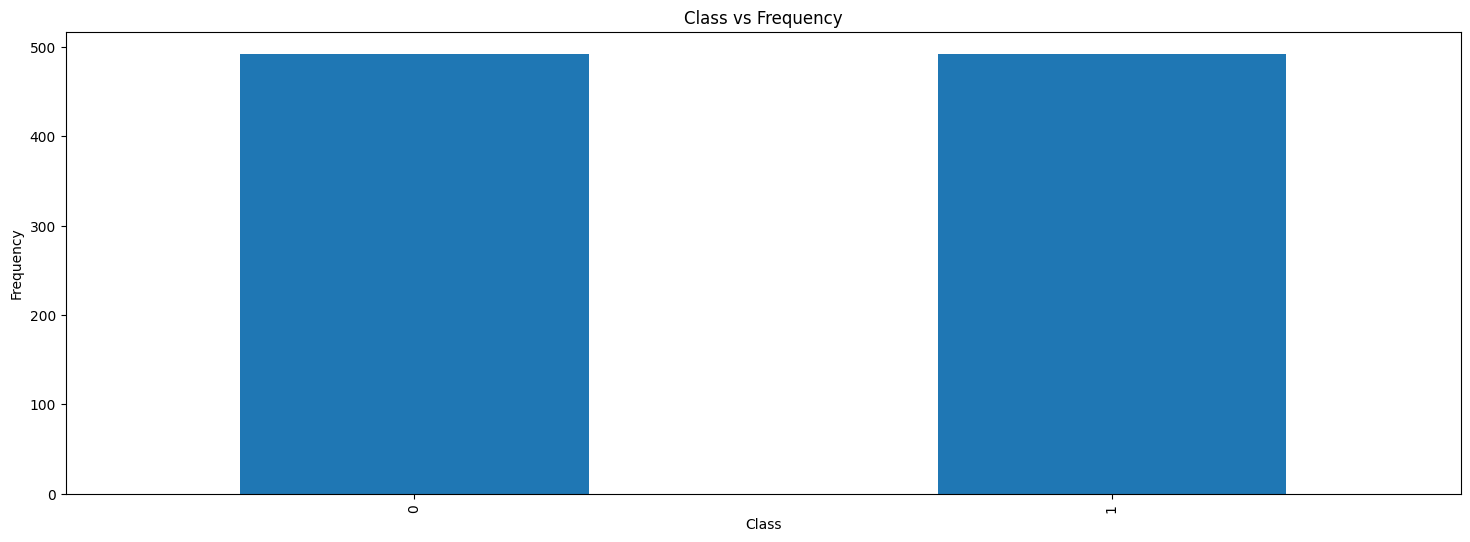

In [324]:
#### Check the count of all the categories in the Class column in the new dataset

plt.figure(figsize=(18,6))
df_new['Class'].value_counts().plot(kind='bar')
plt.title('Class vs Frequency')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.show()

## OBSERVATIONS:

1.  From the above graph, we can see that the frequency count of class 0 is equal to the frequency count of class 1.

2. So now it is a balanced dataset.

In [325]:
#### To check for the duplicate records in the revised dataset

df_new[df_new.duplicated()]

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
102442,68207.0,-13.192671,12.785971,-9.906650,3.320337,-4.801176,5.760059,-18.750889,-37.353443,-0.391540,...,27.202839,-8.887017,5.303607,-0.639435,0.263203,-0.108877,1.269566,0.939407,1.00,1
102443,68207.0,-13.192671,12.785971,-9.906650,3.320337,-4.801176,5.760059,-18.750889,-37.353443,-0.391540,...,27.202839,-8.887017,5.303607,-0.639435,0.263203,-0.108877,1.269566,0.939407,1.00,1
102444,68207.0,-13.192671,12.785971,-9.906650,3.320337,-4.801176,5.760059,-18.750889,-37.353443,-0.391540,...,27.202839,-8.887017,5.303607,-0.639435,0.263203,-0.108877,1.269566,0.939407,1.00,1
102445,68207.0,-13.192671,12.785971,-9.906650,3.320337,-4.801176,5.760059,-18.750889,-37.353443,-0.391540,...,27.202839,-8.887017,5.303607,-0.639435,0.263203,-0.108877,1.269566,0.939407,1.00,1
102446,68207.0,-13.192671,12.785971,-9.906650,3.320337,-4.801176,5.760059,-18.750889,-37.353443,-0.391540,...,27.202839,-8.887017,5.303607,-0.639435,0.263203,-0.108877,1.269566,0.939407,1.00,1
141258,84204.0,-0.937843,3.462889,-6.445104,4.932199,-2.233983,-2.291561,-5.695594,1.338825,-4.322377,...,1.066550,-0.521657,-0.319917,-0.405859,0.906802,1.165784,1.374495,0.729889,0.00,1
141260,84204.0,-1.927453,1.827621,-7.019495,5.348303,-2.739188,-2.107219,-5.015848,1.205868,-4.382713,...,1.376938,-0.792017,-0.771414,-0.379574,0.718717,1.111151,1.277707,0.819081,512.25,1
143334,85285.0,-7.030308,3.421991,-9.525072,5.270891,-4.024630,-2.865682,-6.989195,3.791551,-4.622730,...,1.103398,-0.541855,0.036943,-0.355519,0.353634,1.042458,1.359516,-0.272188,0.00,1
143336,85285.0,-6.713407,3.921104,-9.746678,5.148263,-5.151563,-2.099389,-5.937767,3.578780,-4.684952,...,0.954272,-0.451086,0.127214,-0.339450,0.394096,1.075295,1.649906,-0.394905,252.92,1
150661,93853.0,-6.185857,7.102985,-13.030455,8.010823,-7.885237,-3.974550,-12.229608,4.971232,-4.248307,...,2.502772,0.481691,0.480958,0.360319,-0.293354,-0.199193,-0.203917,0.398927,44.90,1


## OBSERVATIONS:

1.  There are 19 duplicate records in the dataset. So remove them.

In [326]:
#### Drop the duplicates

df_new = df_new.drop_duplicates()

In [327]:
#### To again check for the duplicate records in the dataset

df_new[df_new.duplicated()]

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class


#### OBSERVATIONS:

1.  There are no duplicate records in the dataset.

In [328]:
#### To check for the duplicate records in the revised dataset

df_new[df_new.duplicated()]

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class


## OBSERVATIONS:

1.There are no duplicate records in the dataset.

In [329]:
#### get the length of the revised dataset

print("Length of the revised dataset is:", len(df_new))

Length of the revised dataset is: 965


In [330]:
#### get the shape of the revised dataset

print("Shape of the revised dataset is:", df_new.shape)

Shape of the revised dataset is: (965, 31)


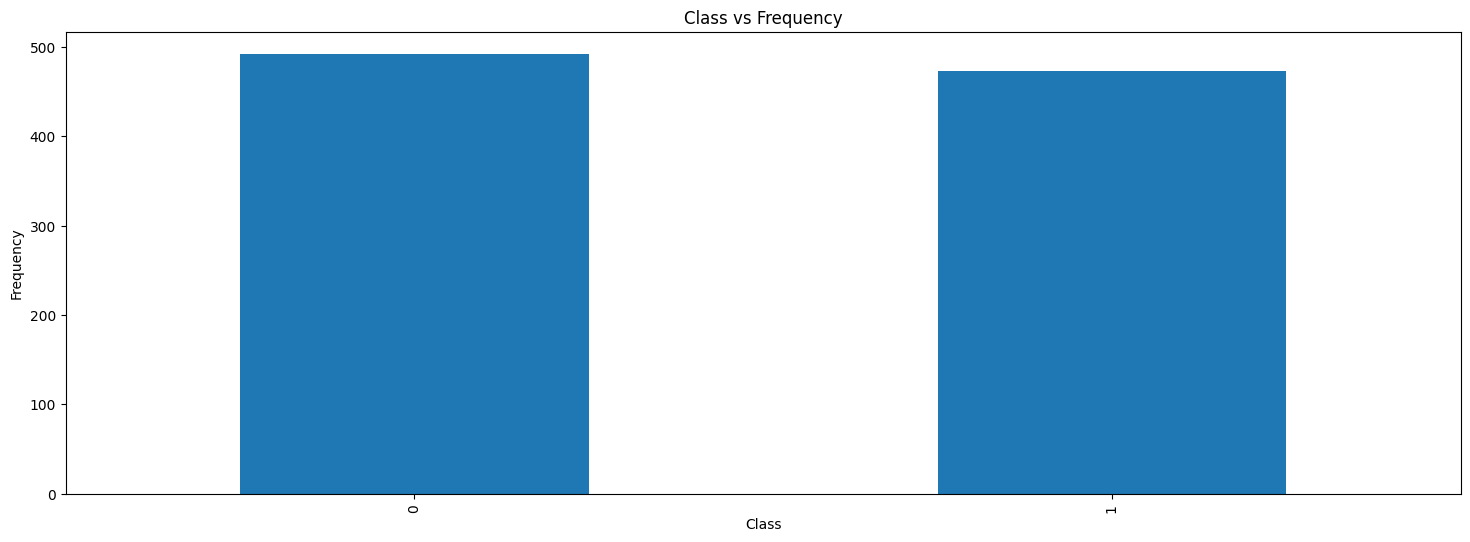

In [331]:
#### Check the count of all the categories in the Class column in the new dataset

plt.figure(figsize=(18,6))
df_new['Class'].value_counts().plot(kind='bar')
plt.title('Class vs Frequency')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.show()

## OBSERVATIONS:

1.  The above graph depicts about the count distributions for the Normal vs Fraud Transactions.

2.  The number of normal transactions are slightly higher than the fraud transactions.

## **Step 5: Perform the Exploratory Data Analysis**

In [332]:
#### get the correlation for each numerical column with respect to other in the dataset

df_new.corr()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
Time,1.000000,0.262415,-0.228190,0.174399,-0.233128,0.297412,0.126580,0.243999,-0.189992,0.176300,...,-0.059065,0.165205,0.076292,0.017640,-0.203871,-0.028985,-0.149465,-0.009818,0.009186,-0.166895
V1,0.262415,1.000000,-0.760202,0.870365,-0.607341,0.852560,0.368368,0.869441,-0.225098,0.646132,...,0.121891,-0.096916,-0.017376,-0.056716,-0.117459,0.013477,0.118067,0.012943,-0.042675,-0.426169
V2,-0.228190,-0.760202,1.000000,-0.851490,0.663446,-0.789657,-0.356265,-0.827980,0.155785,-0.715613,...,-0.088491,0.071947,0.047243,-0.020110,0.109650,0.007735,-0.047660,-0.138733,-0.221541,0.484469
V3,0.174399,0.870365,-0.851490,1.000000,-0.763345,0.847280,0.500436,0.888208,-0.289523,0.759116,...,0.077533,-0.082976,-0.005475,0.029439,-0.113969,-0.037561,-0.003898,0.061562,-0.014845,-0.564896
V4,-0.233128,-0.607341,0.663446,-0.763345,1.000000,-0.565389,-0.433236,-0.712256,0.141206,-0.784741,...,-0.047176,0.138202,0.025922,-0.084401,-0.007784,0.140253,0.037918,-0.004434,0.021835,0.707110
V5,0.297412,0.852560,-0.789657,0.847280,-0.565389,1.000000,0.321843,0.847224,-0.320061,0.653026,...,0.079381,-0.106406,-0.065943,-0.128936,-0.096976,0.058456,0.094659,0.111929,-0.117344,-0.370446
V6,0.126580,0.368368,-0.356265,0.500436,-0.433236,0.321843,1.000000,0.337308,-0.540773,0.371808,...,-0.214186,0.181992,0.272031,0.030062,-0.137822,-0.011707,-0.233449,-0.055981,0.167575,-0.427471
V7,0.243999,0.869441,-0.827980,0.888208,-0.712256,0.847224,0.337308,1.000000,-0.052997,0.778855,...,0.206985,-0.227806,-0.020165,-0.045440,0.036543,0.006084,0.147240,0.121502,0.101492,-0.470058
V8,-0.189992,-0.225098,0.155785,-0.289523,0.141206,-0.320061,-0.540773,-0.052997,1.000000,-0.093704,...,0.394906,-0.359550,-0.320809,0.040781,0.269718,0.011840,0.404319,0.015961,0.009474,0.116715
V9,0.176300,0.646132,-0.715613,0.759116,-0.784741,0.653026,0.371808,0.778855,-0.093704,1.000000,...,0.165667,-0.236165,-0.044828,0.029641,-0.015265,-0.116512,0.046917,0.150922,0.018774,-0.557749


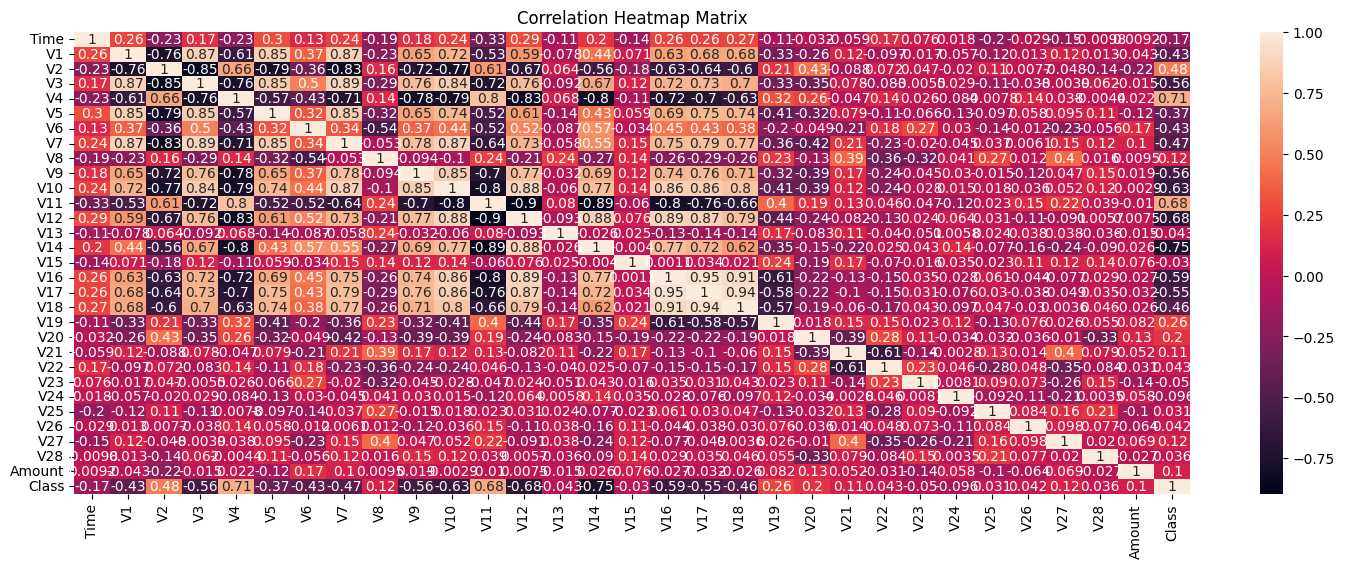

In [333]:
#### get the graphical representation for the correlation for each numerical column with respect to other in the dataset

plt.figure(figsize=(18,6))
sns.heatmap(df_new.corr(), annot=True)
plt.title("Correlation Heatmap Matrix")
plt.show()

#### OBSERVATIONS:

1.  The above graph depicts about the graphical distributions for each numerical distributions with respect to the other in the dataset.s

## **Step 6: Perform Train test split **

In [334]:
#### Divide the dataset into normal and fraud transactions

#### normal transactions

normal = df_new[df_new['Class'] == 0]

#### fraud transactions
fraud = df_new[df_new['Class'] == 1]

In [335]:
### perform feature scaling on the inputs

X_normal = normal.drop(columns='Class')

In [336]:
X_normal

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
249798,154580.0,1.925958,-0.589307,-0.974102,-0.436175,-0.341882,-0.449269,-0.311571,0.066971,0.660746,...,-0.122185,-0.433930,-1.481355,0.580452,0.655875,-0.932918,0.598270,-0.135381,-0.055389,55.50
278356,168176.0,2.037983,-0.154701,-1.167986,0.537046,-0.038161,-0.886548,0.156487,-0.348823,0.669974,...,-0.159201,0.144204,0.779549,-0.019604,0.037772,0.232956,0.728766,-0.059360,-0.069499,11.50
28123,34867.0,-2.284555,-0.475492,1.903762,0.362794,0.116243,0.003288,-0.792549,0.878001,0.518798,...,-0.148615,-0.094460,-0.055395,0.544233,-0.444039,0.383187,0.452441,0.152914,-0.029347,9.07
17811,28934.0,1.191896,0.177092,0.420666,1.141171,-0.508842,-0.911981,0.049874,-0.119563,0.246069,...,-0.178189,-0.056313,-0.244766,-0.023098,0.340071,0.492023,-0.436639,0.010092,0.026550,25.20
192857,129885.0,1.972363,-0.132482,-0.769689,0.313480,-0.437924,-0.724807,-0.502440,0.007302,1.287646,...,-0.187919,-0.242999,-0.580234,0.461809,0.945736,-0.553749,-0.335194,0.021502,0.000008,3.85
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
268430,163203.0,-1.236165,0.513444,1.370722,-0.532542,-0.652602,0.522913,0.396490,0.760510,-0.263488,...,0.130651,0.028149,-0.457808,0.194001,0.601905,0.282463,-0.456401,-0.119516,0.016736,154.70
151090,94583.0,2.078419,0.078552,-2.189645,0.155381,0.766861,-1.211777,0.657963,-0.550585,1.566585,...,-0.226376,0.003633,0.269795,-0.027098,0.585976,0.404218,0.176895,-0.125028,-0.075208,38.41
113838,73223.0,1.208269,-0.064852,1.056225,1.215621,-0.771369,0.087856,-0.630626,0.166992,1.033479,...,-0.179643,-0.111306,-0.123578,-0.054125,-0.161721,0.466882,-0.372626,0.069048,0.029787,0.01
194147,130459.0,-4.533607,-1.962265,-1.375059,-1.945860,2.827294,-2.730527,0.781216,-0.432543,0.180402,...,-0.935060,-0.080372,0.480922,-2.143575,-0.133961,1.412607,0.954096,-0.384181,0.056539,20.00


In [337]:
X_fraud = fraud.drop(columns='Class')

In [338]:
X_fraud

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
541,406.0,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.537387,1.391657,-2.770089,...,0.126911,0.517232,-0.035049,-0.465211,0.320198,0.044519,0.177840,0.261145,-0.143276,0.00
623,472.0,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,...,2.102339,0.661696,0.435477,1.375966,-0.293803,0.279798,-0.145362,-0.252773,0.035764,529.00
4920,4462.0,-2.303350,1.759247,-0.359745,2.330243,-0.821628,-0.075788,0.562320,-0.399147,-0.238253,...,-0.430022,-0.294166,-0.932391,0.172726,-0.087330,-0.156114,-0.542628,0.039566,-0.153029,239.93
6108,6986.0,-4.397974,1.358367,-2.592844,2.679787,-1.128131,-1.706536,-3.496197,-0.248778,-0.247768,...,-0.171608,0.573574,0.176968,-0.436207,-0.053502,0.252405,-0.657488,-0.827136,0.849573,59.00
6329,7519.0,1.234235,3.019740,-4.304597,4.732795,3.624201,-1.357746,1.713445,-0.496358,-1.282858,...,0.009061,-0.379068,-0.704181,-0.656805,-1.632653,1.488901,0.566797,-0.010016,0.146793,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279863,169142.0,-1.927883,1.125653,-4.518331,1.749293,-1.566487,-2.010494,-0.882850,0.697211,-2.064945,...,1.252967,0.778584,-0.319189,0.639419,-0.294885,0.537503,0.788395,0.292680,0.147968,390.00
280143,169347.0,1.378559,1.289381,-5.004247,1.411850,0.442581,-1.326536,-1.413170,0.248525,-1.127396,...,0.226138,0.370612,0.028234,-0.145640,-0.081049,0.521875,0.739467,0.389152,0.186637,0.76
280149,169351.0,-0.676143,1.126366,-2.213700,0.468308,-1.120541,-0.003346,-2.234739,1.210158,-0.652250,...,0.247968,0.751826,0.834108,0.190944,0.032070,-0.739695,0.471111,0.385107,0.194361,77.89
281144,169966.0,-3.113832,0.585864,-5.399730,1.817092,-0.840618,-2.943548,-2.208002,1.058733,-1.632333,...,0.306271,0.583276,-0.269209,-0.456108,-0.183659,-0.328168,0.606116,0.884876,-0.253700,245.00


In [339]:
Y_fraud = fraud['Class']

In [340]:
Y_fraud

,Class
541,1
623,1
4920,1
6108,1
6329,1
...,...
279863,1
280143,1
280149,1
281144,1


In [341]:
#### perform train test split operation on the training data

from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(
    X_normal            ,
    test_size   =  0.2  ,
    random_state = 42
)


In [342]:
X_train

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
131879,79769.0,0.793987,-1.082892,0.926736,0.298662,-1.403481,-0.009595,-0.554119,0.197963,1.047639,...,0.275254,-0.074471,-0.470185,-0.093061,0.403634,0.007679,0.906941,-0.079514,0.036171,202.18
66468,52068.0,-0.169259,-2.558091,0.751670,1.269721,-1.583680,1.509506,-0.379488,0.511853,1.242125,...,1.024147,0.347071,-0.049585,-0.492800,-0.204886,-0.123443,0.479493,-0.065047,0.113813,626.02
23262,32661.0,-1.705290,-1.545280,2.603350,0.791866,-0.589450,-0.215612,-0.619800,0.393167,-1.273790,...,0.321064,-0.062630,-0.402031,0.534397,0.439407,0.132431,-0.295076,0.026771,0.125219,204.00
53760,46133.0,-0.487469,0.266945,1.745003,-1.233457,-0.063960,-1.026250,0.404658,-0.045570,0.166473,...,0.070359,-0.087988,-0.188954,0.004631,0.544807,-0.366803,0.668090,-0.006235,-0.162087,3.76
127526,78362.0,1.190129,0.135449,0.190197,0.025126,-0.331553,-1.086988,0.317034,-0.241614,-0.477548,...,0.042294,-0.351842,-1.123876,0.186391,0.568863,0.062227,0.586627,-0.104001,0.002266,34.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132677,80078.0,-0.367263,1.045788,1.167802,-0.126083,0.214873,-0.470635,0.599997,0.106457,-0.599476,...,0.129140,-0.234032,-0.655953,-0.056288,-0.054702,-0.153085,0.075402,0.238611,0.084571,6.99
35870,38301.0,-1.093496,-0.314159,2.206636,-0.045053,0.807644,2.057107,-0.712446,1.000272,0.169503,...,-0.018172,0.196384,0.619758,0.086337,-1.323300,-0.573457,0.402569,0.152427,0.108108,24.10
98323,66617.0,-0.381846,0.904521,0.834957,-0.602963,1.025293,0.890065,0.500902,0.321756,-0.561702,...,0.145422,-0.259471,-0.675001,-0.215702,-1.726271,-0.060943,0.190105,0.275927,0.090354,4.49
87383,61660.0,1.044781,-1.793907,0.342119,-1.343012,-1.750916,-0.329168,-0.910576,-0.046616,-1.951006,...,0.137097,-0.205557,-0.806747,-0.068684,-0.040285,0.050344,-0.430482,-0.006291,0.055081,239.65


In [343]:
X_test

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
107771,70609.0,1.200603,-0.076936,0.831135,0.948348,-0.328602,0.790430,-0.672716,0.295544,0.667834,...,-0.075645,-0.086577,-0.048161,-0.161239,-0.832189,0.551853,-0.354235,0.069978,0.016071,4.99
152240,97148.0,-2.316000,-0.207995,-0.024298,0.648699,2.341564,-0.213354,2.008098,-1.529259,1.253541,...,-0.234465,-0.552541,0.668035,0.152189,0.254106,1.192709,0.647110,-1.086973,-0.061417,29.26
257908,158404.0,2.204102,-0.698620,-1.629590,-1.203482,0.004332,-0.408896,-0.377916,-0.233340,-0.953534,...,0.119812,0.469490,1.337721,-0.069177,0.373311,0.288439,0.037599,-0.042771,-0.068795,25.00
48679,43741.0,1.077594,-0.091075,1.243342,1.713352,-0.618778,0.624652,-0.463501,0.227160,1.098970,...,-0.141494,-0.403072,-0.637928,0.071212,0.109174,0.459297,-0.513251,0.097596,0.031180,12.14
141066,84103.0,-7.245548,0.093858,-1.817620,0.783996,0.961529,0.905233,-2.784139,-9.027739,-0.318309,...,-3.573384,-0.008708,-0.181338,2.349526,-0.891902,1.399956,-0.170339,1.347884,-1.179729,173.35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95828,65490.0,1.277305,-1.249980,0.481120,-1.253532,-1.642737,-0.927870,-0.727027,-0.299450,-1.994541,...,-0.019053,-0.370311,-0.954666,0.095691,0.361975,0.107568,-0.496656,0.019065,0.051418,134.00
139035,82977.0,1.151431,-0.052437,1.278827,1.346008,-1.006422,-0.206452,-0.577897,0.106512,0.932957,...,-0.150294,-0.065165,0.003970,-0.001416,0.388550,0.405433,-0.408413,0.070565,0.037864,9.99
181741,125107.0,1.915342,0.659728,-1.608316,3.515381,1.103214,-0.271277,0.768926,-0.223929,-1.705092,...,-0.236446,0.128845,0.237917,-0.040640,-0.519152,0.290084,0.082120,-0.093630,-0.073789,37.92
8550,11503.0,-0.260929,0.283170,1.943299,-0.062001,-0.645027,-0.481639,-0.153698,-0.072105,2.367917,...,0.178904,0.094246,0.830464,-0.198564,0.401409,-0.121882,-0.372779,0.213478,0.156460,22.81


## OBSERVATIONS:

1.  Autoencoder Anamoly detection algorithm is exclusively trained on the normal data, so it takes the normal data as the input.

2.  Here the test size is 20 %

3.  After performing the train_test_split operation, X_train and X_test are only produced as OneClassSVM is an unsupervised anamoly based machine learning algorithm

4. Autoencoder Anamoly detection does not produced any labels or the target variables during the model training due to its unsupervised based nature.

In [344]:
#### perform feature scaling on the inputs

from sklearn.preprocessing import StandardScaler

#### create an object for Standard Scaler

sc = StandardScaler()

#### using the object for Standard Scaler, transform the inputs
X_train_scaled = sc.fit_transform(X_train)

In [345]:
X_train_scaled

array([[-0.37993819,  0.41791698, -0.86116998, ..., -0.3055095 ,
         0.16277622,  0.93947825],
       [-0.96285267, -0.15390993, -1.99955684, ..., -0.25558092,
         0.54610682,  4.07230033],
       [-1.3712358 , -1.06576861, -1.21798755, ...,  0.06130367,
         0.60241898,  0.95293082],
       ...,
       [-0.65669683, -0.2801118 ,  0.67248363, ...,  0.9212026 ,
         0.43028479, -0.52175145],
       [-0.7610074 ,  0.56679983, -1.40984858, ..., -0.05279814,
         0.25613662,  1.21643853],
       [-2.05357886, -0.44732091, -0.0598164 , ...,  0.8385861 ,
         0.6455594 , -0.37015136]])

In [346]:
X_test_scaled = sc.transform(X_test)

In [347]:
X_test_scaled

array([[-0.57269284,  0.65930297, -0.08489054, ...,  0.21042338,
         0.06353837, -0.51805569],
       [-0.01423043, -1.4283141 , -0.18602624, ..., -3.78249284,
        -0.319033  , -0.33866349],
       [ 1.27478475,  1.25502601, -0.56463352, ..., -0.17870019,
        -0.35545792, -0.37015136],
       ...,
       [ 0.57411317,  1.08360481,  0.48358082, ..., -0.35422789,
        -0.38011369, -0.27465292],
       [-1.81646538, -0.20832978,  0.19299721, ...,  0.7056753 ,
         0.75666143, -0.38633879],
       [-1.08239843, -0.6976359 ,  0.57683821, ...,  0.04461474,
         0.41143117, -0.54754786]])

In [348]:
X_fraud_scaled = sc.transform(X_fraud)

In [349]:
X_fraud_scaled

array([[-2.04998049, -1.42607417,  1.48079982, ...,  0.87018598,
        -0.72318344, -0.55493938],
       [-2.04859164, -1.86021581, -2.46196225, ..., -0.90346838,
         0.16076607,  3.355175  ],
       [-1.96462974, -1.42080439,  1.33206202, ...,  0.10546381,
        -0.77133517,  1.21850815],
       ...,
       [ 1.50514339, -0.45481961,  0.84367786, ...,  1.29801003,
         0.94378599,  0.02078616],
       [ 1.51808489, -1.90194377,  0.42658145, ...,  3.02282924,
        -1.26836653,  1.25598316],
       [ 1.52612335,  1.12909829,  0.09677294, ..., -0.02077702,
        -0.09138966, -0.24057801]])

#### OBSERVATIONS:

1.  Autoencoder Anamoly detection algorithm is exclusively trained on the normal data. So the model training is done on the input normal data.

2.  Then only input training and testing data is produced as Autoencoder Anamoly detection algorithm is an unsupervised machine learning based algorithm as it does not produce any labels during model training

3.  fit_transform is only used for training as it learns all the mean and standard deviation from the learning data.

4.  transform is used for testing as it used the mean and std from the training data.

5.  X_fraud_scaled uses transform only as it has its own mean and std and only uses it for testing purpose otherwise data leakage is caused.